# **X-Ray Image Classification System (Custom CNN)** 

## **Images Analyzing & Preprocessing**

Link of the dataset : https://universe.roboflow.com/m-eqf3t/chest-x-ray-chee0/dataset/3

### **Step 1 — Import Libraries**

**Bringing in all the tools we need before starting — like setting up the workbench before building something**

In [1]:
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

### **STEP 2 — Verify: Same Dimensions (224×224) & Grayscale**

**Scanning all images across every split to confirm they are all 224×224 pixels and grayscale — catching any corrupted or misformatted files before they silently break the model during training**

[INFO] Dataset root detected: C:\Users\LOQ\Desktop\data_zaid\DS\Dataset
[INFO] Contents: ['test', 'train', 'valid']

[INFO] Reading split: train ...
[INFO] Reading split: test ...
[INFO] Reading split: valid ...

  X-RAY DATASET ANALYSIS REPORT

──────────────────────────────────────────────────────────────────────
  SPLIT : TRAIN   (total images: 14774)
──────────────────────────────────────────────────────────────────────
  Class                    Count   Wrong Size   Not Gray  Status
  ────────────────────── ───────  ───────────  ─────────  ──────────────
  covid                     2500         2500          0  ✗  2500 wrong size
  lung_opacity              4204         4204          0  ✗  4204 wrong size
  normal                    7156         7156          0  ✗  7156 wrong size
  viral_pnuemonia            914          914          0  ✗  914 wrong size

  Dimension (224x299) : ✗ ISSUES FOUND
  Grayscale              : ✓ ALL PASS

────────────────────────────────────────────────

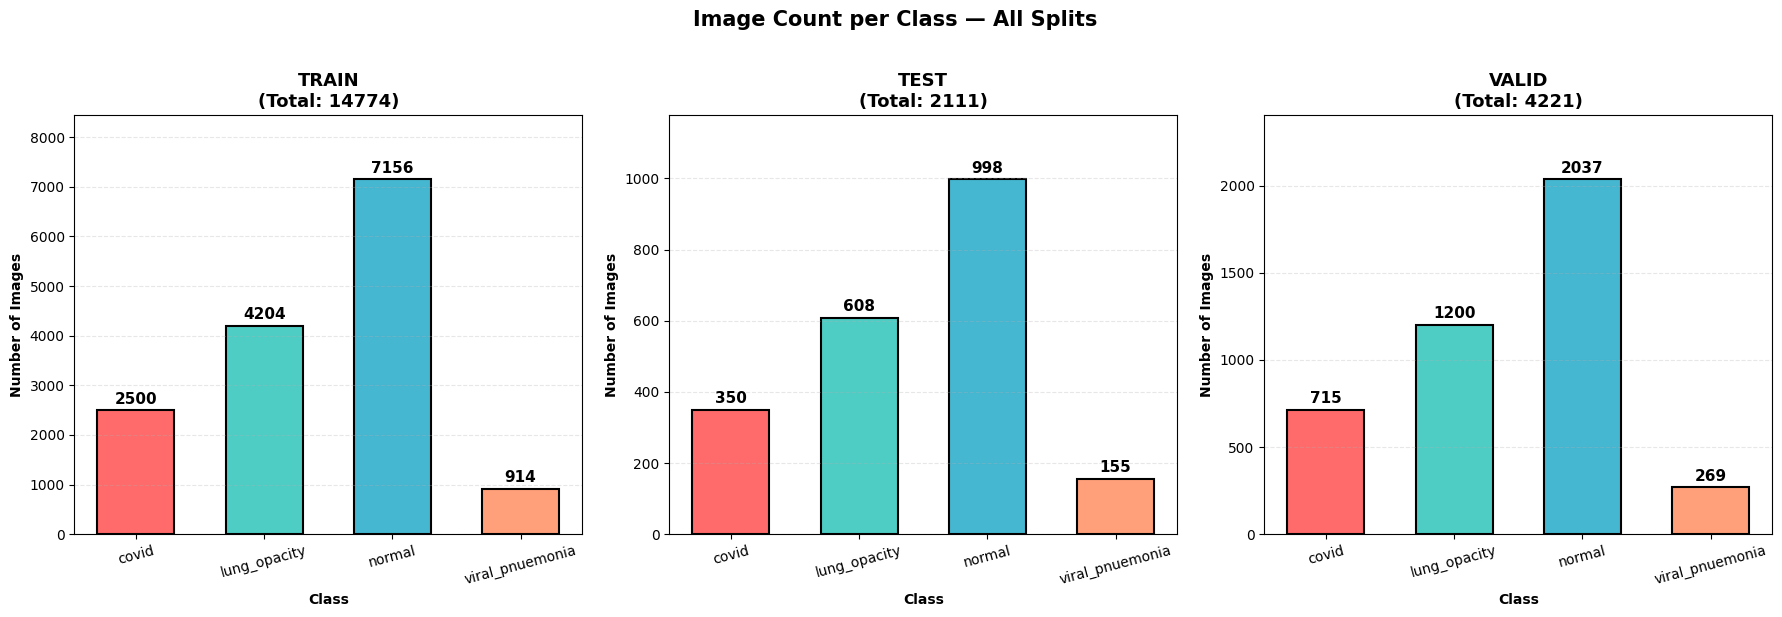

In [2]:
def find_dataset_root():
    candidates = [
        Path("."),
        Path(".."),
        Path("DATASET"),
        Path("../DATASET"),
    ]
    for p in candidates:
        p = p.resolve()
        if any((p / split).exists() for split in ["train", "test", "valid"]):
            return p
    return Path(".").resolve()

BASE_PATH = find_dataset_root()
print(f"[INFO] Dataset root detected: {BASE_PATH}")
print(f"[INFO] Contents: {[f.name for f in BASE_PATH.iterdir() if f.is_dir()]}\n")

SPLITS  = ["train", "test", "valid"]
CLASSES = ["covid", "lung_opacity", "normal", "viral_pnuemonia"]

TARGET_WIDTH  = 224
TARGET_HEIGHT = 299



def is_grayscale(image: Image.Image) -> bool:
    if image.mode in ("L", "1"):
        return True
    if image.mode in ("RGB", "RGBA"):
        img = image.convert("RGB")
        r, g, b = img.split()
        return r.tobytes() == g.tobytes() == b.tobytes()
    return False


def analyze_split(split_path: Path):
    results = {}
    for class_name in CLASSES:
        class_path = split_path / class_name
        if not class_path.exists():
            results[class_name] = {"count": 0, "wrong_size": 0, "not_gray": 0}
            continue

        exts  = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
        files = sorted({f for f in class_path.iterdir()
                        if f.is_file() and f.suffix in exts})

        wrong_size, not_gray = 0, 0
        for f in files:
            try:
                with Image.open(f) as img:
                    w, h = img.size
                    if w != TARGET_WIDTH or h != TARGET_HEIGHT:
                        wrong_size += 1
                    if not is_grayscale(img):
                        not_gray += 1
            except Exception as e:
                print(f"  [ERROR] {f.name}: {e}")
                wrong_size += 1
                not_gray   += 1

        results[class_name] = {"count": len(files),
                                "wrong_size": wrong_size,
                                "not_gray": not_gray}
    return results


all_split_results = {}

for split in SPLITS:
    split_path = BASE_PATH / split
    if not split_path.exists():
        print(f"[WARNING] Not found: {split_path}")
        continue
    print(f"[INFO] Reading split: {split} ...")
    all_split_results[split] = analyze_split(split_path)

if not all_split_results:
    print("\n[ERROR] No splits found! Check BASE_PATH.")
    print(f"        Current working directory: {Path('.').resolve()}")
    print(f"        BASE_PATH used: {BASE_PATH}")
    raise SystemExit


print("\n" + "=" * 70)
print("  X-RAY DATASET ANALYSIS REPORT")
print("=" * 70)

for split, class_results in all_split_results.items():
    split_total       = sum(v["count"]      for v in class_results.values())
    split_size_ok     = all(v["wrong_size"] == 0 for v in class_results.values())
    split_gray_ok     = all(v["not_gray"]   == 0 for v in class_results.values())

    print(f"\n{'─'*70}")
    print(f"  SPLIT : {split.upper()}   (total images: {split_total})")
    print(f"{'─'*70}")
    print(f"  {'Class':<22} {'Count':>7}  {'Wrong Size':>11}  {'Not Gray':>9}  Status")
    print(f"  {'─'*22} {'─'*7}  {'─'*11}  {'─'*9}  {'─'*14}")

    for cls, info in class_results.items():
        ws, ng, cnt = info["wrong_size"], info["not_gray"], info["count"]
        if   cnt == 0:          status = "⚠  NOT FOUND"
        elif ws == 0 and ng ==0: status = "✓  OK"
        else:
            parts = []
            if ws: parts.append(f"{ws} wrong size")
            if ng: parts.append(f"{ng} not gray")
            status = "✗  " + ", ".join(parts)
        print(f"  {cls:<22} {cnt:>7}  {ws:>11}  {ng:>9}  {status}")

    print(f"\n  Dimension ({TARGET_WIDTH}x{TARGET_HEIGHT}) : "
          f"{'✓ ALL PASS' if split_size_ok else '✗ ISSUES FOUND'}")
    print(f"  Grayscale              : "
          f"{'✓ ALL PASS' if split_gray_ok else '✗ ISSUES FOUND'}")

print(f"\n{'═'*70}\n")


n_splits = len(all_split_results)
colors   = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

fig, axes = plt.subplots(1, n_splits, figsize=(6 * n_splits, 6), sharey=False)
axes = [axes] if n_splits == 1 else list(axes)

for ax, (split, class_results) in zip(axes, all_split_results.items()):
    counts      = [class_results[c]["count"] for c in CLASSES]
    max_count   = max(counts) if max(counts) > 0 else 10
    bars        = ax.bar(CLASSES, counts, color=colors,
                         edgecolor='black', linewidth=1.5, width=0.6)

    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_count * 0.01,
                str(cnt), ha='center', va='bottom',
                fontweight='bold', fontsize=11)

    ax.set_title(f"{split.upper()}\n(Total: {sum(counts)})",
                 fontweight='bold', fontsize=13)
    ax.set_ylabel("Number of Images", fontweight='bold')
    ax.set_xlabel("Class", fontweight='bold')
    ax.set_ylim(0, max_count * 1.18)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle("Image Count per Class — All Splits",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('xray_frequency_chart.png', dpi=300, bbox_inches='tight')
print("Chart saved → xray_frequency_chart.png")
plt.show()

### **STEP 3 — Configuration & Hyperparameters** 

**Centralizing all settings in one place so we can change them easily without hunting through the code**

In [3]:
BASE_PATH   = Path(".")
CLASSES     = ["covid", "lung_opacity", "normal", "viral_pnuemonia"]
IMG_SIZE    = (224, 224)
MAX_PER_CLASS = 1100          # Classes with fewer images keep all
BATCH_SIZE  = 32
SEED        = 42

### **Step 4 — Data Loading, Balancing & Preprocessing** 

**Loading images from disk, capping each class at 1100 samples to fix the class imbalance, converting to grayscale, resizing to 224×224, and normalizing pixel values to [0,1] — so the model receives clean, consistent input ready for training**

In [ ]:
def load_balanced_paths(split: str, max_per_class: int = MAX_PER_CLASS):
    """
    Returns (file_paths, labels) with at most max_per_class samples per class.
    Classes with fewer images are kept as-is (e.g. viral_pnuemonia ~914).
    """
    split_path = BASE_PATH / split
    all_paths, all_labels = [], []
 
    for label_idx, class_name in enumerate(CLASSES):
        class_path = split_path / class_name
        if not class_path.exists():
            print(f"[WARNING] Not found: {class_path}")
            continue
 
        exts  = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
        files = [f for f in class_path.iterdir()
                 if f.is_file() and f.suffix in exts]
 
        
        random.seed(SEED)
        if len(files) > max_per_class:
            files = random.sample(files, max_per_class)
 
        all_paths  += files
        all_labels += [label_idx] * len(files)
        print(f"  [{split}] {class_name:<22}: {len(files):>5} images")
 
    return all_paths, all_labels

In [5]:
def preprocess_image(path: Path) -> np.ndarray:
    with Image.open(path) as img:
        img = img.convert("L")
        img = img.resize(IMG_SIZE)
        arr = np.array(img, dtype=np.float32) / 255.0
        return arr[..., np.newaxis]  # (224, 224) → (224, 224, 1)

In [ ]:
def make_tf_dataset(split: str, shuffle: bool = True) -> tf.data.Dataset:
    print(f"\n[INFO] Building dataset for split: {split.upper()}")
    paths, labels = load_balanced_paths(split)

    combined = list(zip(paths, labels))
    if shuffle:
        random.seed(SEED)
        random.shuffle(combined)

    paths  = [str(x[0]) for x in combined]   # strings for tf
    labels = [x[1]      for x in combined]   # plain int list

    num_classes = len(CLASSES)

    def load_fn(path, label):
        img = tf.numpy_function(
            func=lambda p: preprocess_image(Path(p.decode())),
            inp=[path],
            Tout=tf.float32
        )
        img.set_shape((*IMG_SIZE, 1))
        label_oh = tf.one_hot(label, num_classes)
        return img, label_oh

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

In [7]:
train_ds = make_tf_dataset("train", shuffle=True)
test_ds  = make_tf_dataset("test",  shuffle=False)
valid_ds = make_tf_dataset("valid", shuffle=False)


[INFO] Building dataset for split: TRAIN
  [train] covid                 :  1100 images
  [train] lung_opacity          :  1100 images
  [train] normal                :  1100 images
  [train] viral_pnuemonia       :   914 images

[INFO] Building dataset for split: TEST
  [test] covid                 :   350 images
  [test] lung_opacity          :   608 images
  [test] normal                :   998 images
  [test] viral_pnuemonia       :   155 images

[INFO] Building dataset for split: VALID
  [valid] covid                 :   715 images
  [valid] lung_opacity          :  1100 images
  [valid] normal                :  1100 images
  [valid] viral_pnuemonia       :   269 images


In [8]:
for images, labels_batch in train_ds.take(1):
    print(f"\n[Sanity Check]")
    print(f"  Batch images shape : {images.shape}")   # (32, 224, 224, 1)
    print(f"  Batch labels shape : {labels_batch.shape}")  # (32, 4)
    print(f"  Pixel range        : [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")
 
print("\n✓ Generators ready — train_ds / test_ds / valid_ds")


[Sanity Check]
  Batch images shape : (32, 224, 224, 1)
  Batch labels shape : (32, 4)
  Pixel range        : [0.00, 1.00]

✓ Generators ready — train_ds / test_ds / valid_ds


## **Model Architecture & Building**

![Alt text](Architecture.png)

### **Step 1 — Import Libraries**

**Importing everything required to design the CNN, control the training process, and measure how well the model performs**

In [9]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

### **Step 2 — Model Architecture**

**Building a Custom CNN from scratch with 4 Conv Blocks (32→64→128→256 filters), BatchNormalization for stable training, GlobalAveragePooling to reduce parameters, and a fully connected head with Dropout to prevent overfitting — outputting probabilities for 4 classes**

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [11]:
inputs = tf.keras.Input(shape=(224, 224, 1))
x = data_augmentation(inputs)   

In [12]:
x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

In [13]:
x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

In [14]:
x = layers.Conv2D(128, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

In [15]:
x = layers.Conv2D(256, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

In [16]:
x = layers.GlobalAveragePooling2D()(x)

In [17]:
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.6)(x)


In [18]:
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)

In [19]:
outputs = layers.Dense(4, activation='softmax')(x)

In [20]:
model = models.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 1)]     0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496 

### **Step 3 — Model Compiling & Callbacks**

**Setting up the optimizer (Adam with Cosine LR Decay), loss function (Categorical Crossentropy), and EarlyStopping callback — preparing the model for training**

In [21]:
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.0003,
    decay_steps=10 * len(train_ds),   
    alpha=1e-6                        
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)


### **Step 4 — Model Training**

**Fitting the model on the training data while monitoring validation performance — using EarlyStopping to restore the best weights automatically when the model plateaus**

In [23]:
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    callbacks=[early_stop]   
)

Epoch 1/20
132/132 [==============================] - 16s 96ms/step - loss: 1.1889 - accuracy: 0.4706 - val_loss: 1.6369 - val_accuracy: 0.3753
Epoch 2/20
132/132 [==============================] - 13s 92ms/step - loss: 0.8786 - accuracy: 0.6407 - val_loss: 1.9163 - val_accuracy: 0.3455
Epoch 3/20
132/132 [==============================] - 13s 92ms/step - loss: 0.7406 - accuracy: 0.7145 - val_loss: 1.4825 - val_accuracy: 0.3794
Epoch 4/20
132/132 [==============================] - 13s 91ms/step - loss: 0.6680 - accuracy: 0.7437 - val_loss: 0.9017 - val_accuracy: 0.6153
Epoch 5/20
132/132 [==============================] - 13s 91ms/step - loss: 0.5958 - accuracy: 0.7734 - val_loss: 0.6230 - val_accuracy: 0.7692
Epoch 6/20
132/132 [==============================] - 13s 91ms/step - loss: 0.5362 - accuracy: 0.7988 - val_loss: 0.5823 - val_accuracy: 0.7657
Epoch 7/20
132/132 [==============================] - 13s 91ms/step - loss: 0.4990 - accuracy: 0.8130 - val_loss: 0.6040 - val_accuracy:

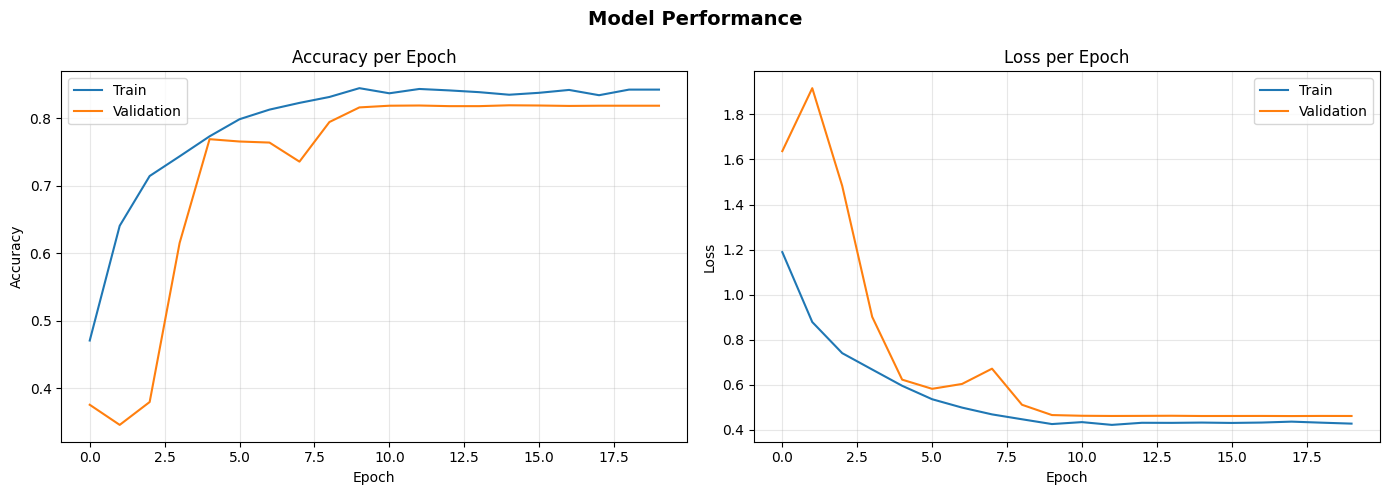

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Model Performance', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

### **Step 5 — Model Evaluation on Test Set**

**Running the trained model on unseen test data to measure real-world performance — reporting accuracy, loss, error rate per class, confusion matrix, and classification report**

In [25]:
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

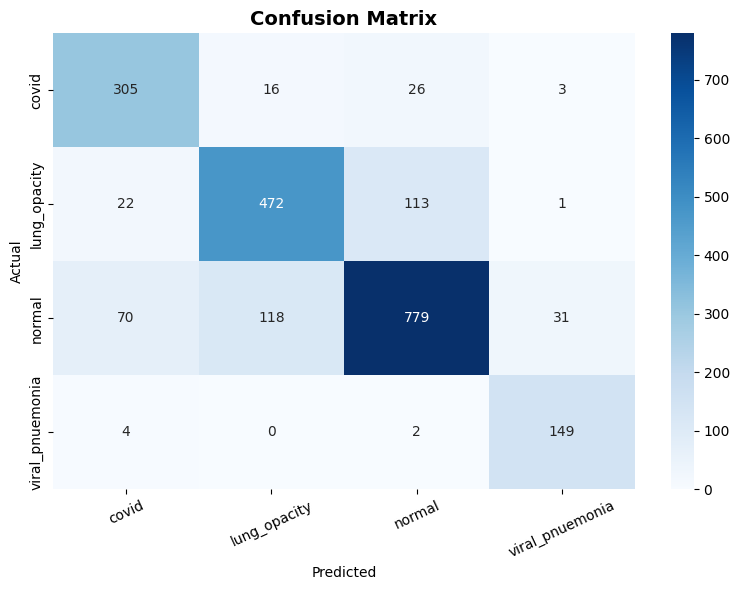

In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES,
            yticklabels=CLASSES)
plt.title('Confusion Matrix', fontweight='bold', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print("=" * 50)
print("  Error Rate per Class")
print("=" * 50)

for i, class_name in enumerate(CLASSES):
    class_mask   = y_true == i
    class_total  = class_mask.sum()
    class_wrong  = (y_pred[class_mask] != i).sum()
    error_rate   = class_wrong / class_total * 100
    print(f"  {class_name:<22}: {error_rate:.2f}%  ({class_wrong}/{class_total} wrong)")

overall_error = (y_true != y_pred).sum() / len(y_true) * 100
print("=" * 50)
print(f"  {'Overall Error Rate':<22}: {overall_error:.2f}%")
print(f"  {'Overall Accuracy':<22}: {100 - overall_error:.2f}%")
print("=" * 50)

  Error Rate per Class
  covid                 : 12.86%  (45/350 wrong)
  lung_opacity          : 22.37%  (136/608 wrong)
  normal                : 21.94%  (219/998 wrong)
  viral_pnuemonia       : 3.87%  (6/155 wrong)
  Overall Error Rate    : 19.23%
  Overall Accuracy      : 80.77%
